In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
mall_customers = pd.read_csv('Mall_Customers.csv')
mall_customers

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
mall_customers = pd.get_dummies(mall_customers)
#df['col_name'] = df['col_name'].astype(int)
mall_customers['Gender_Female'] = mall_customers['Gender_Female'].astype(int)
mall_customers.drop('Gender_Male', axis=1, inplace=True) 
mall_customers

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_Female
0,1,19,15,39,0
1,2,21,15,81,0
2,3,20,16,6,1
3,4,23,16,77,1
4,5,31,17,40,1
...,...,...,...,...,...
195,196,35,120,79,1
196,197,45,126,28,1
197,198,32,126,74,0
198,199,32,137,18,0


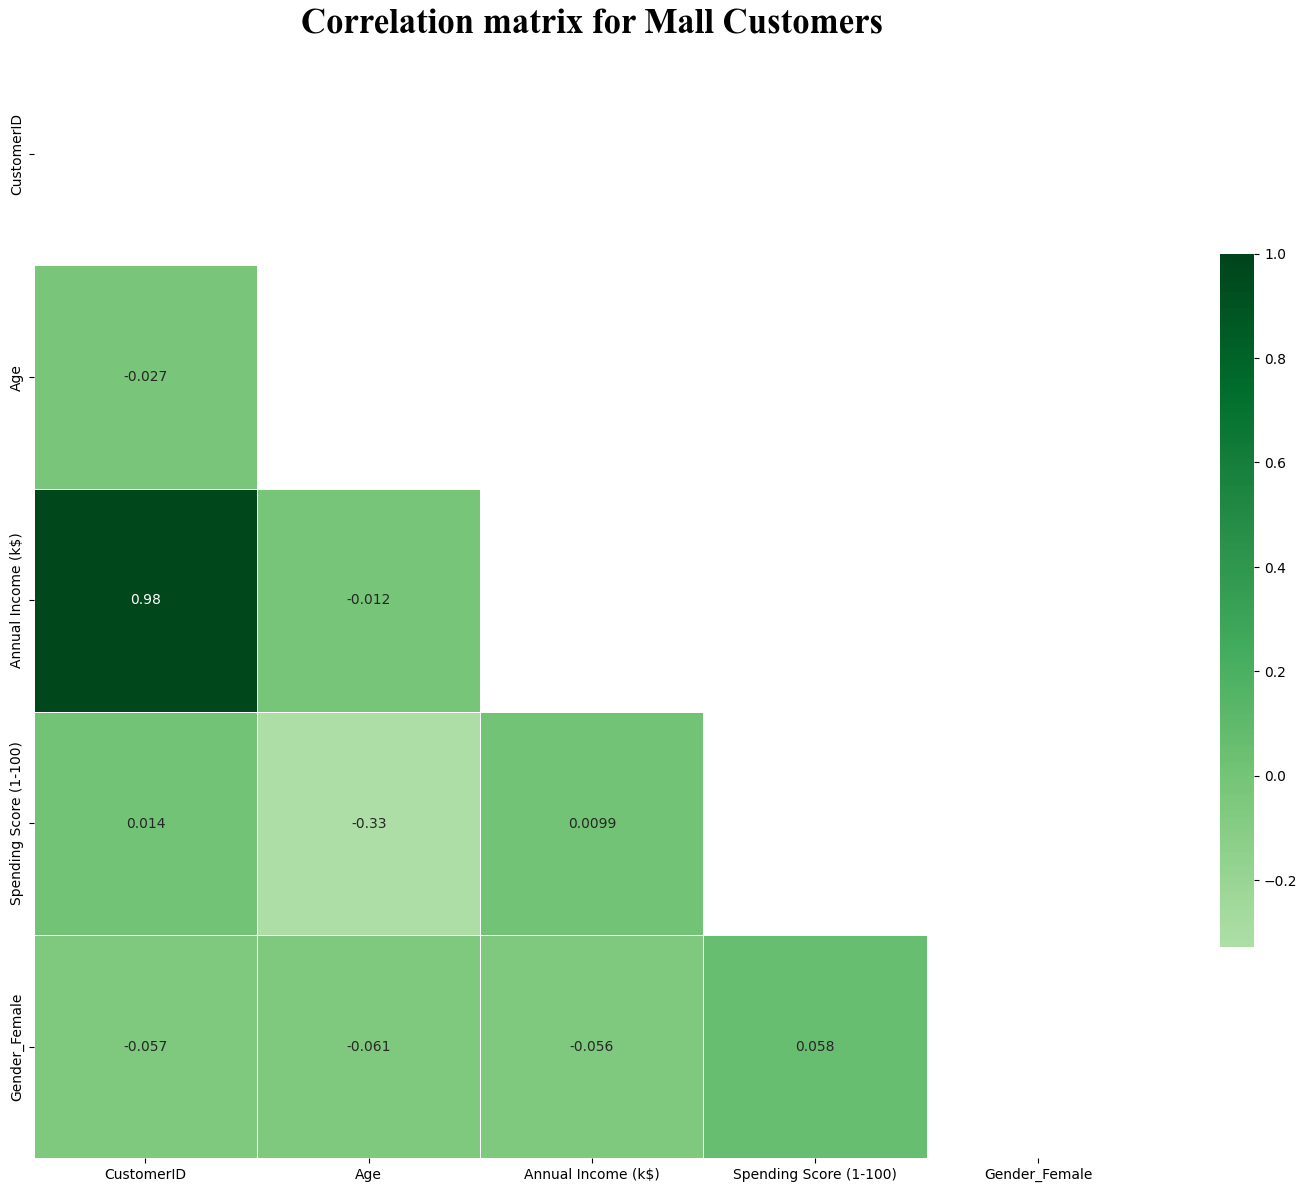

In [4]:
#sns.set(style="whitegrid")

# Generate a mask for the upper triangle
mask = np.zeros_like(mall_customers.corr(numeric_only = True), dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(18, 18))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(mall_customers.corr(numeric_only = True), mask=mask, cmap='Greens', vmax=1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True)

plt.title("Correlation matrix for Mall Customers", font='Times new roman', fontsize=25, fontweight='bold')
#plt.savefig("Correlation matrix for Mall Customers.png")
plt.show()

Scatterplot

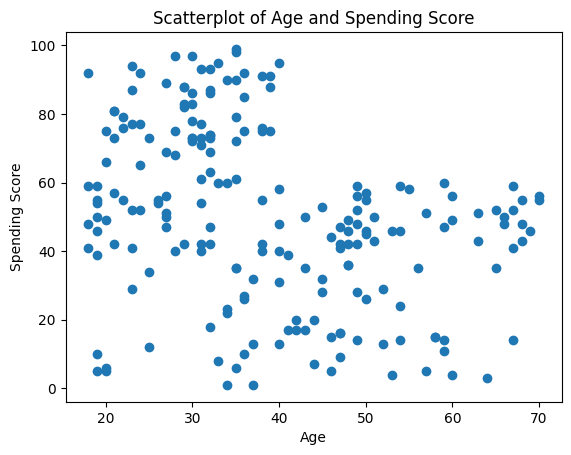

In [7]:
plt.scatter(mall_customers['Age'], mall_customers['Spending Score (1-100)'])
plt.xlabel('Age')
plt.ylabel('Spending Score')
plt.title('Scatterplot of Age and Spending Score')
plt.show()


Histogram

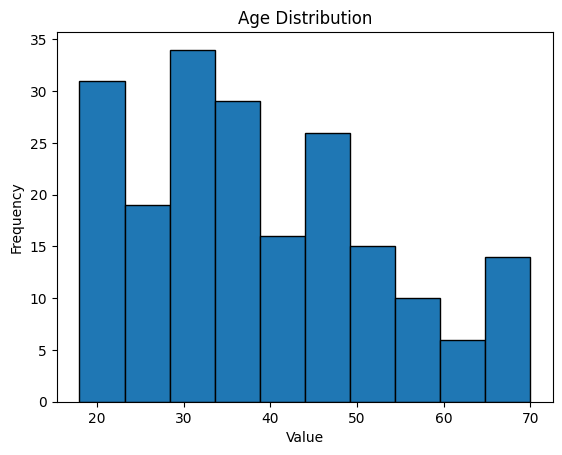

In [36]:
# Plot a histogram of the 'values' column
mall_customers['Age'].plot.hist(bins=10, title='Age Distribution', edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

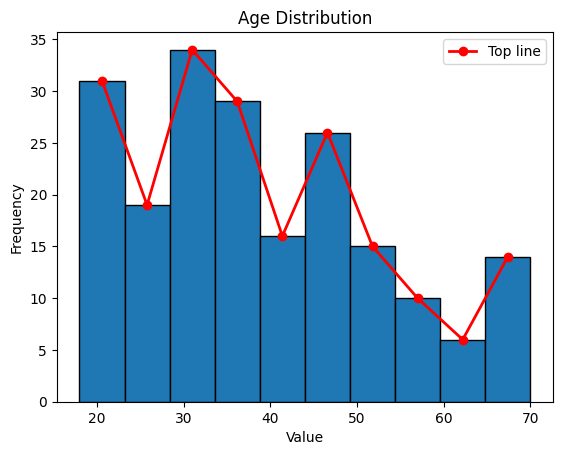

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Compute the histogram data
counts, bin_edges = np.histogram(mall_customers['Age'], bins=10)

# Plot the histogram
plt.hist(mall_customers['Age'], bins=10, edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Plot a line along the tops
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])  # midpoint of each bin
plt.plot(bin_centers, counts, color='red', marker='o', linewidth=2, label='Top line')

plt.legend()
plt.show()

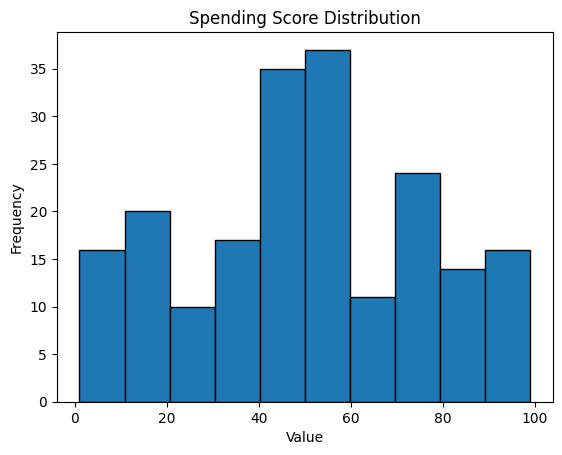

In [46]:
# Plot a histogram of the 'values' column
mall_customers['Spending Score (1-100)'].plot.hist(bins=10, title='Spending Score Distribution', edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

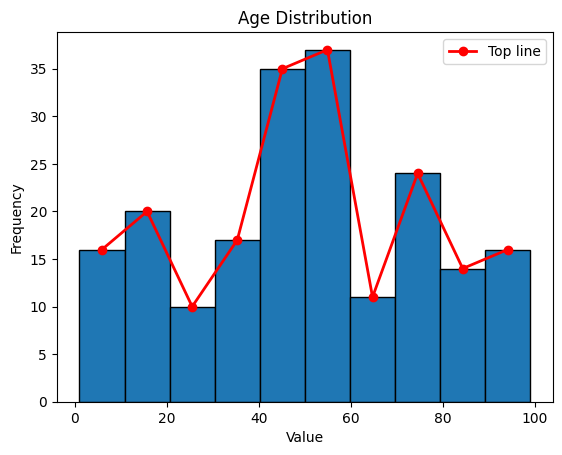

In [48]:
import matplotlib.pyplot as plt
import numpy as np

# Compute the histogram data
counts, bin_edges = np.histogram(mall_customers['Spending Score (1-100)'], bins=10)

# Plot the histogram
plt.hist(mall_customers['Spending Score (1-100)'], bins=10, edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Plot a line along the tops
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])  # midpoint of each bin
plt.plot(bin_centers, counts, color='red', marker='o', linewidth=2, label='Top line')

plt.legend()
plt.show()

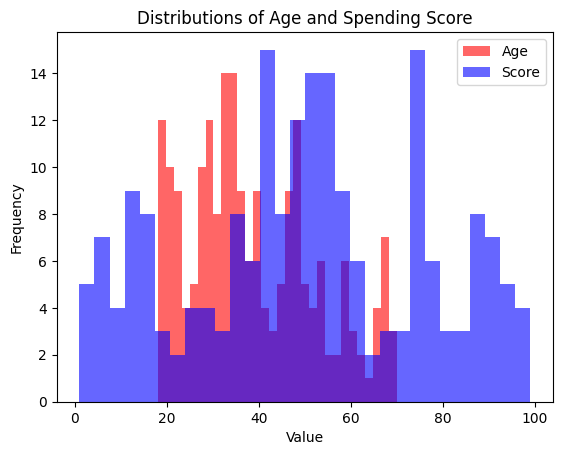

In [57]:
import matplotlib.pyplot as plt
import numpy as np

# Generate sample data for two distributions
#data1 = np.random.normal(loc=0, scale=1, size=1000)  # Mean 0, std dev 1
#data2 = np.random.normal(loc=2, scale=1.5, size=1000) # Mean 2, std dev 1.5

data1 = mall_customers['Age']
data2 = mall_customers['Spending Score (1-100)']


# Create the overlapping histograms
plt.hist(data1, bins=30, alpha=0.6, label='Age', color='red')
plt.hist(data2, bins=30, alpha=0.6, label='Score', color='blue')


# Add labels, title, and legend
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Distributions of Age and Spending Score')
plt.legend(loc='upper right')

# Display the plot
plt.show()

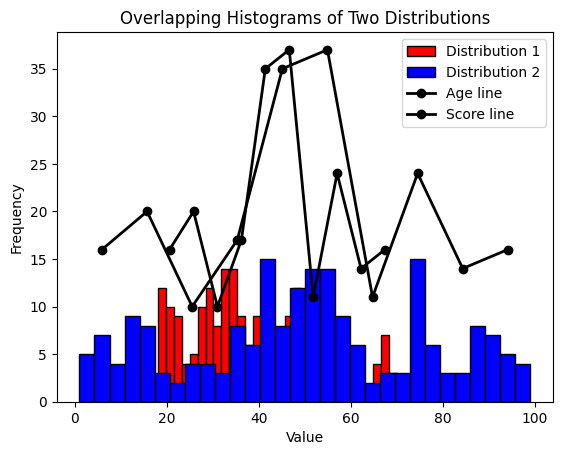

In [52]:
import matplotlib.pyplot as plt
import numpy as np

# Generate sample data for two distributions
#data1 = np.random.normal(loc=0, scale=1, size=1000)  # Mean 0, std dev 1
#data2 = np.random.normal(loc=2, scale=1.5, size=1000) # Mean 2, std dev 1.5

data1 = mall_customers['Age']
data2 = mall_customers['Spending Score (1-100)']


# Create the overlapping histograms
plt.hist(data1, bins=30, alpha=1, label='Distribution 1', color='red', edgecolor='black')
plt.hist(data2, bins=30, alpha=1, label='Distribution 2', color='blue', edgecolor='black')

# Compute the histogram data
age_counts, age_bin_edges = np.histogram(mall_customers['Age'], bins=10)
score_counts, score_bin_edges = np.histogram(mall_customers['Spending Score (1-100)'], bins=10)

# Plot a line along the tops
age_bin_centers = 0.5 * (age_bin_edges[1:] + age_bin_edges[:-1])  # midpoint of each bin
plt.plot(age_bin_centers, counts, color='black', marker='o', linewidth=2, label='Age line')

# Plot a line along the tops
score_bin_centers = 0.5 * (score_bin_edges[1:] + score_bin_edges[:-1])  # midpoint of each bin
plt.plot(score_bin_centers, counts, color='black', marker='o', linewidth=2, label='Score line')


# Add labels, title, and legend
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Overlapping Histograms of Two Distributions')
plt.legend(loc='upper right')

# Display the plot
plt.show()

K-Means

In [8]:
X = mall_customers.drop(columns=['CustomerID'])

In [9]:
import matplotlib.pyplot as plt
from kneed import KneeLocator
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

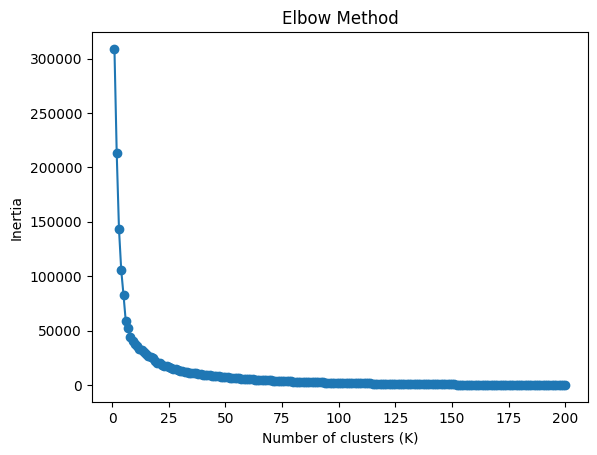

In [10]:
inertias = []
for i in range(1, len(X) + 1): # Max clusters can be equal to number of data points
    kmeans = KMeans(n_clusters=i, random_state=0, n_init='auto')
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.plot(range(1, len(X) + 1), inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.show()

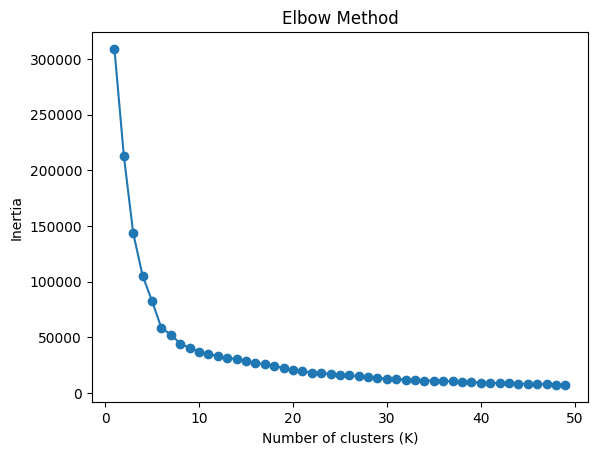

In [11]:
inertias = []
for i in range(1, 50): # Reduced range for legibility
    kmeans = KMeans(n_clusters=i, random_state=0, n_init='auto')
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.plot(range(1, 50), inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.show()

In [12]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init='auto')
kmeans.fit(X)

KMeans(n_clusters=6, random_state=42)

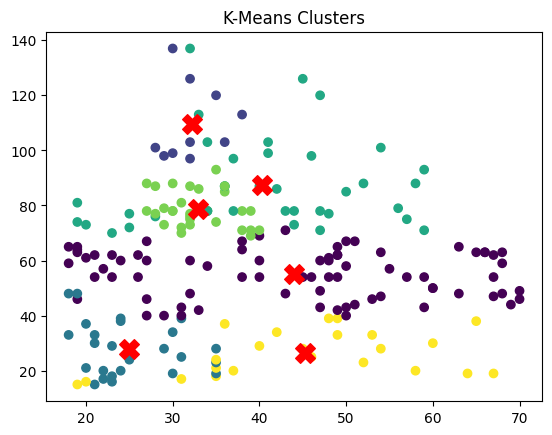

In [14]:
labels = kmeans.labels_
centroids = kmeans.cluster_centers_
import matplotlib.pyplot as plt

plt.scatter(X.iloc[:,0], X.iloc[:,1], c=labels, cmap='viridis', alpha=1)
plt.scatter(centroids[:,0], centroids[:,1], c='red', marker='X', s=200)
plt.title("K-Means Clusters")
plt.show()

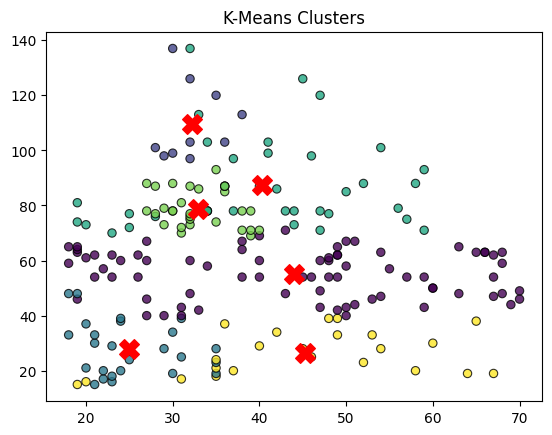

In [15]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init='auto')
kmeans.fit(X)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_
import matplotlib.pyplot as plt

plt.scatter(X.iloc[:,0], X.iloc[:,1], c=labels, cmap='viridis', alpha=0.8, edgecolors='black', linewidth=0.8)
plt.scatter(centroids[:,0], centroids[:,1], c='red', marker='X', s=200)
plt.title("K-Means Clusters")
plt.show()

In [ ]:
PCA

/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


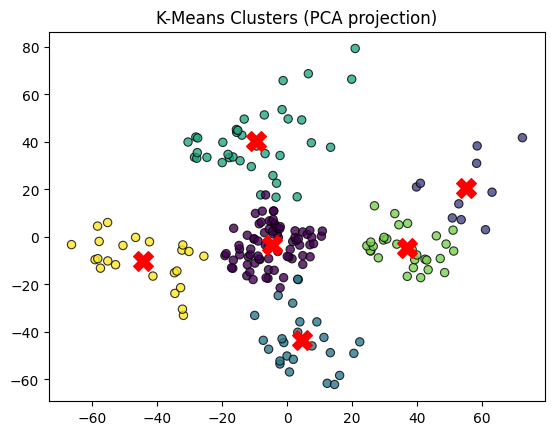

In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis', alpha=0.8, edgecolors='black', linewidth=0.8)
centroids_pca = pca.transform(centroids)
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], c='red', marker='X', s=200)
plt.title("K-Means Clusters (PCA projection)")
plt.show()

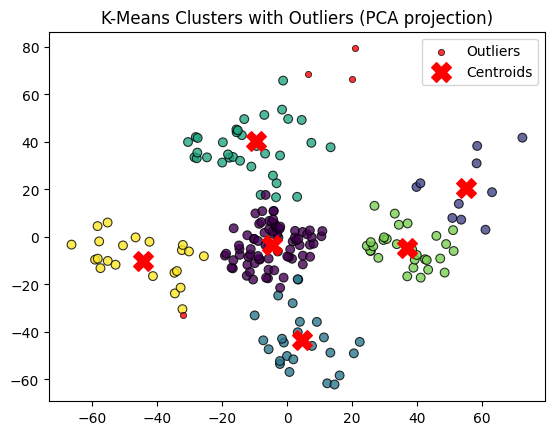

In [17]:
# Compute distances of each point to its assigned cluster centroid
distances = np.linalg.norm(X - centroids[labels], axis=1)

# Define outliers as the top 2% farthest from their centroid
threshold = np.percentile(distances, 98)
outliers = distances > threshold

# Plot regular points
plt.scatter(X_pca[~outliers, 0], X_pca[~outliers, 1],
            c=labels[~outliers], cmap='viridis',
            alpha=0.8, s=40, edgecolors='black', linewidth=0.8)

# Plot outliers separately in red
plt.scatter(X_pca[outliers, 0], X_pca[outliers, 1],
            c='red', marker='o', alpha=0.8, s=20, label='Outliers', edgecolors='black', linewidth=0.6)

# Plot centroids
plt.scatter(centroids_pca[:,0], centroids_pca[:,1],
            c='red', marker='X', s=200, label='Centroids')

plt.title("K-Means Clusters with Outliers (PCA projection)")
plt.legend()
plt.show()

/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


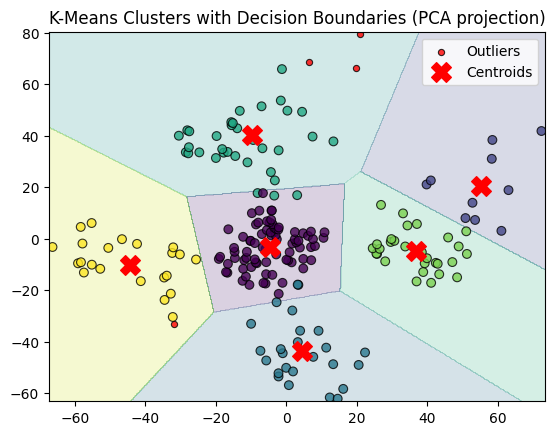

In [22]:
import numpy as np
from matplotlib.colors import ListedColormap

# Create a mesh grid covering the PCA space
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

# Predict cluster labels for each point
Z = kmeans.predict(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()]))
Z = Z.reshape(xx.shape)

# Plot the decision boundary regions
plt.contourf(xx, yy, Z, alpha=0.2, cmap='viridis')

# Plot regular points
plt.scatter(X_pca[~outliers, 0], X_pca[~outliers, 1],
            c=labels[~outliers], cmap='viridis',
            alpha=0.8, s=40, edgecolors='black', linewidth=0.8)

# Plot outliers separately in red
plt.scatter(X_pca[outliers, 0], X_pca[outliers, 1],
            c='red', marker='o', alpha=0.8, s=20, label='Outliers', edgecolors='black', linewidth=0.8)

# Plot centroids
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='red', marker='X', s=200, label='Centroids')

plt.title("K-Means Clusters with Decision Boundaries (PCA projection)")
plt.legend()
plt.show()

DBSCAN with PCA